In [1]:
from resources.imports import *

from scipy.interpolate import griddata
from matplotlib.path import Path # Still needed for masking
from scipy.spatial import Delaunay

In [2]:
LAT = 'tri'
nnx = 30
DIS = 'per'
mode = 'ductile'
nSim = 1

frame = 75

os.chdir('C:/Users/exy053/Documents/continuum/')

In [3]:
simDir = f'{mode.capitalize()}-{LAT}-{nnx}-{DIS}-{nSim}'
dispsCSV = f'{simDir}/frame{frame}.csv'
NodesElemsCSV = f'{simDir}/NodesElems.csv'

with open(NodesElemsCSV) as f:
    lines = f.readlines()
nodesStart = lines.index([line for line in lines if "*Nodes" in line][0])+1
elemsStart = lines.index([line for line in lines if "*Elems" in line][0])+1

disps = pd.read_csv(dispsCSV).to_numpy()[:, 1:]
nodes = pd.read_csv(NodesElemsCSV, names=['node', 'x', 'y'], skiprows=nodesStart, nrows=elemsStart-2).to_numpy()[:, 1:]
elems = pd.read_csv(NodesElemsCSV, names=['elem', 'n1', 'n2'], skiprows=elemsStart).to_numpy()[:, 1:]
elems = elems - 1

# nodes, disps, elems

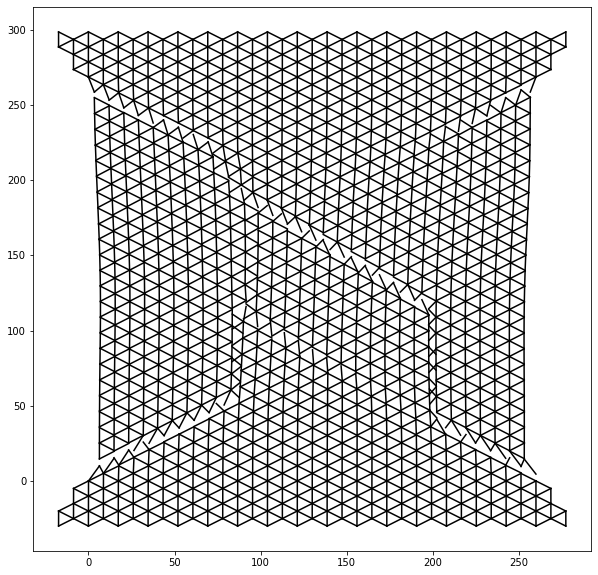

In [4]:
plt.figure(figsize=(10, 10))
for elem in elems:
    n1 = elem[0]
    n2 = elem[1]
    plt.plot([nodes[n1][0]+disps[n1][0], nodes[n2][0]+disps[n2][0]], [nodes[n1][1]+disps[n1][1], nodes[n2][1]+disps[n1][1]], 'k')

Found 1858 triangles from edge connectivity.
Calculated strains for 1858 triangles.
Strain range: min=-0.0001, max=0.8169


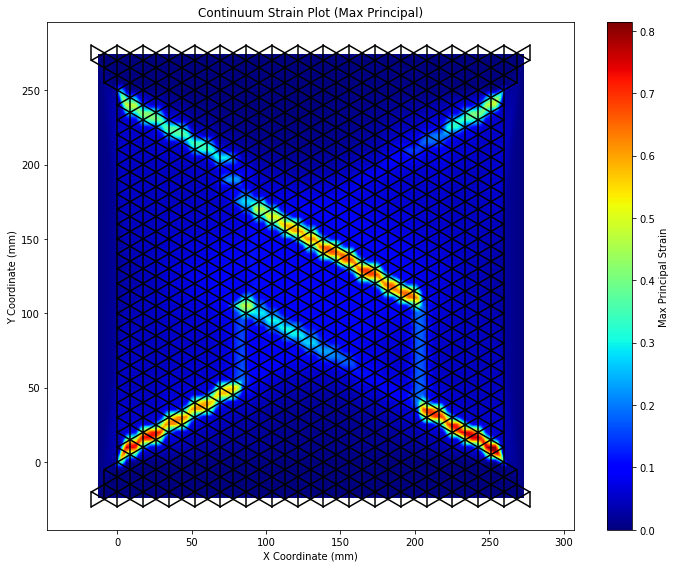

In [6]:
def calculate_green_lagrange_strain(initial_triangle_coords, final_triangle_coords, strain_type='max_principal'):
    P1 = initial_triangle_coords[0, :]
    P2 = initial_triangle_coords[1, :]
    P3 = initial_triangle_coords[2, :]
    p1 = final_triangle_coords[0, :]
    p2 = final_triangle_coords[1, :]
    p3 = final_triangle_coords[2, :]
    dX = np.array([P2 - P1, P3 - P1]).T
    dx = np.array([p2 - p1, p3 - p1]).T

    F = dx @ np.linalg.inv(dX)
    I = np.eye(2)
    E_tensor = 0.5 * (F.T @ F - I)
    E_xx = E_tensor[0, 0]
    E_yy = E_tensor[1, 1]
    E_xy = E_tensor[0, 1]

    if strain_type == 'max_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.max(eigenvalues)
    elif strain_type == 'min_principal':
        eigenvalues = np.linalg.eigvalsh(E_tensor)
        return np.min(eigenvalues)
    elif strain_type == 'von_mises':
        e1, e2 = np.linalg.eigvalsh(E_tensor)
        return np.sqrt(e1**2 + e2**2 - e1*e2)
    elif strain_type == 'E_xx':
        return E_xx
    elif strain_type == 'E_yy':
        return E_yy
    elif strain_type == 'E_xy':
        return E_xy

def find_triangles_from_edges(edge_list_node_pairs, num_total_nodes):
    adj = [set() for _ in range(num_total_nodes)]
    for n1, n2 in edge_list_node_pairs:
        adj[n1].add(n2)
        adj[n2].add(n1)

    found_triangles_set = set()
    for u in range(num_total_nodes):
        if not adj[u]:
            continue
        neighbors_of_u = list(adj[u])
        for i in range(len(neighbors_of_u)):
            v = neighbors_of_u[i]
            if v <= u: 
                continue
            for w in adj[v]:
                if w <= v: 
                    continue
                if w in adj[u]:
                    triangle_nodes = tuple(sorted((u, v, w)))
                    found_triangles_set.add(triangle_nodes)
        
    return np.array(list(found_triangles_set), dtype=int)

initial_coords = nodes
displacements = disps
edge_node_pairs = elems

initial_coords = np.asarray(initial_coords)
displacements = np.asarray(displacements)
final_coords = initial_coords + displacements

num_total_nodes = initial_coords.shape[0]

triangles_node_indices = find_triangles_from_edges(edge_node_pairs, num_total_nodes)

print(f"Found {triangles_node_indices.shape[0]} triangles from edge connectivity.")

element_strains = []
element_centroids_initial = []

strain_measure_to_plot = 'max_principal'

for i, tri_indices in enumerate(triangles_node_indices):
    initial_triangle_nodes = initial_coords[tri_indices]
    final_triangle_nodes = final_coords[tri_indices]

    strain = calculate_green_lagrange_strain(initial_triangle_nodes, final_triangle_nodes, strain_type=strain_measure_to_plot)
    
    element_strains.append(strain)
    centroid = np.mean(initial_triangle_nodes, axis=0)
    element_centroids_initial.append(centroid)

element_strains = np.array(element_strains)
element_centroids_initial = np.array(element_centroids_initial)

print(f"Calculated strains for {len(element_strains)} triangles.")
print(f"Strain range: min={np.min(element_strains):.4f}, max={np.max(element_strains):.4f}")

pad_factor = 0.05
x_min_overall, y_min_overall = np.min(initial_coords, axis=0)
x_max_overall, y_max_overall = np.max(initial_coords, axis=0)
x_range = x_max_overall - x_min_overall
y_range = y_max_overall - y_min_overall

grid_x_coords = np.linspace(x_min_overall - pad_factor * x_range, x_max_overall + pad_factor * x_range, 200)
grid_y_coords = np.linspace(y_min_overall - pad_factor * y_range, y_max_overall + pad_factor * y_range, 200)
GX, GY = np.meshgrid(grid_x_coords, grid_y_coords)

strain_grid = griddata(element_centroids_initial, element_strains, (GX, GY), method='linear')

tri_centroids = Delaunay(element_centroids_initial)
grid_points_flat = np.vstack((GX.ravel(), GY.ravel())).T
simplex_indices = tri_centroids.find_simplex(grid_points_flat)

mask = simplex_indices != -1
mask = mask.reshape(GX.shape)

strain_grid[~mask] = np.nan


fig, ax = plt.subplots(figsize=(10, 8))

s_min = np.nanmin(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)
s_max = np.nanmax(strain_grid if np.any(~np.isnan(strain_grid)) else element_strains)

cmap_imshow = plt.get_cmap('jet')
cmap_imshow.set_bad(color='white', alpha=1) 
im = ax.imshow(strain_grid, extent=(grid_x_coords[0], grid_x_coords[-1], grid_y_coords[0], grid_y_coords[-1]),
               origin='lower', cmap=cmap_imshow, aspect='auto',
               vmin=s_min, vmax=s_max, interpolation='bilinear')
for i in elems:
    n1 = i[0]
    n2 = i[1]
    ax.plot([initial_coords[n1][0], initial_coords[n2][0]], [initial_coords[n1][1], initial_coords[n2][1]], 'k')

plt.colorbar(im, label=f'{strain_measure_to_plot.replace("_", " ").title()} Strain')
plt.title(f'Continuum Strain Plot ({strain_measure_to_plot.replace("_", " ").title()})')
plt.xlabel('X Coordinate (mm)')
plt.ylabel('Y Coordinate (mm)')
plt.axis('equal')
plt.tight_layout()
plt.show()